DSA 210 - Introduction to Data Science
Project: Predicting Road Network Failure Probabilities for Post-Disaster Drone Routing
Phase: Environment Setup

Description:
This cell installs the necessary Python dependencies required to run the analysis
in a Google Colab environment.
- 'osmnx': For fetching street networks and building footprints from OpenStreetMap.
- 'geopandas': For spatial data processing and geographic operations (e.g., spatial joins).
- 'matplotlib': For plotting graphs and generating spatial maps.
- 'scipy': For conducting statistical hypothesis tests (e.g., Pearson correlation).

In [3]:
!pip install osmnx geopandas matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00


Phase: Data Collection

Description: This script performs the initial data collection phase of the project. It uses the OSMnx library to extract the primary road network (drivable edges and nodes) and enrichment data (building footprints) for a specified high-risk geographic area (Caferağa, Kadıköy). To ensure reproducibility and reduce API calls, the extracted spatial data is saved locally in GeoJSON format for subsequent Exploratory Data Analysis (EDA) and spatial joining operations.


Data fetching process started for Caferağa, Kadıköy, Istanbul, Turkey...
Total Number of Road Segments (Arcs): 332
Total Number of Buildings: 2065
Data successfully saved in .geojson format.


<Axes: >

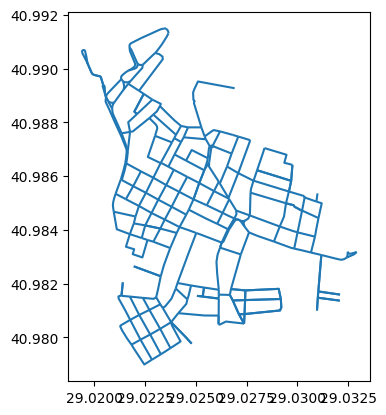

In [4]:
import osmnx as ox
import geopandas as gpd

# 1. Define the Region
# Caferağa (Moda) was selected to not exceed the 1000 segment limit by much.
place_name = "Caferağa, Kadıköy, Istanbul, Turkey"

print(f"Data fetching process started for {place_name}...")

# 2. Fetch Road Network Data (Primary Data)
# We are only fetching drivable roads using the 'drive' option[cite: 63].
graph = ox.graph_from_place(place_name, network_type='drive')

# Convert the graph to GeoDataFrame format (nodes: intersections, edges: road segments/arcs)
nodes, edges = ox.graph_to_gdfs(graph)

# 3. Fetch Building Data (Enrichment Data)
# We are retrieving building footprints for data enrichment, which is a project requirement[cite: 18, 64].
buildings = ox.features_from_place(place_name, tags={'building': True})

# 4. Dataset Summary Information
print(f"Total Number of Road Segments (Arcs): {len(edges)}")
print(f"Total Number of Buildings: {len(buildings)}")

# 5. Save to File
# We save the data to local files to avoid fetching it from the internet every time.
# Do not forget to add these files to your GitHub repository.
try:
    edges.to_file("kadikoy_roads.geojson", driver='GeoJSON')
    nodes.to_file("kadikoy_nodes.geojson", driver='GeoJSON')
    buildings.to_file("kadikoy_buildings.geojson", driver='GeoJSON')
    print("Data successfully saved in .geojson format.")
except Exception as e:
    print(f"An error occurred during saving: {e}")

# 6. Visualization for Verification (EDA start)
edges.plot()

Phase: Data Enrichment & Spatial Analysis:

Description: This script performs spatial joining to enrich the road network data with building
density metrics. It converts the data to a metric Coordinate Reference System (CRS),
creates a 20-meter buffer around each road segment, and counts the intersecting buildings.
Finally, it calculates the 'structural_density' (buildings per road length) and
visualizes the results for Exploratory Data Analysis (EDA).
"""

/usr/local/lib/python3.12/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Process completed! First 5 rows:
                                  osmid  building_count  structural_density
0.0                           132474412            20.0            0.224673
1.0                           132474412             6.0            0.125636
2.0                           678909319             4.0            0.161804
3.0                           236488997             3.0            0.070827
4.0  [43942177, 1237459845, 1462853486]             2.0            0.011882


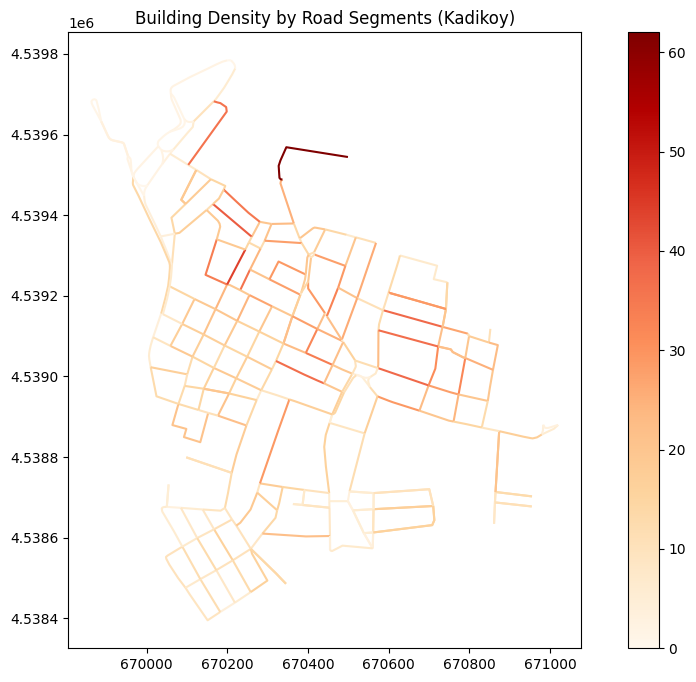

In [5]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the saved data
roads = gpd.read_file("kadikoy_roads.geojson")
buildings = gpd.read_file("kadikoy_buildings.geojson")

# CRITICAL STEP: Convert the coordinate reference system to a metric one (UTM Zone 35N - ideal for Istanbul)
# This is mandatory to perform buffer operations in meters.
roads = roads.to_crs(epsg=32635)
buildings = buildings.to_crs(epsg=32635)

# 2. Create Buffer Zones
# We add a 20-meter area of effect to the left and right of each road.
roads_buffer = roads.copy()
roads_buffer['geometry'] = roads_buffer.geometry.buffer(20)

# 3. Spatial Join
# We find which buildings fall within which road buffer.
# The 'predicate' parameter can be 'intersects' or 'within' depending on the OSMnx version.
joined = gpd.sjoin(buildings, roads_buffer, how="inner", predicate="intersects")

# 4. Calculate the Number of Buildings per Road
# We count how many buildings intersect with each road (index_right).
building_counts = joined.groupby("index_right").size().reset_index(name="building_count")

# 5. Add this information back to the main road data
roads = roads.merge(building_counts, left_index=True, right_on="index_right", how="left")
roads["building_count"] = roads["building_count"].fillna(0) # Fill roads with no buildings with 0

# 6. Calculate Structural Density
# Formula: Number of Buildings / Road Length
roads["structural_density"] = roads["building_count"] / roads.geometry.length

print("Process completed! First 5 rows:")
print(roads[["osmid", "building_count", "structural_density"]].head())

# 7. Visualization (for EDA)
fig, ax = plt.subplots(figsize=(12, 8))
roads.plot(column="building_count", cmap="OrRd", legend=True, ax=ax)
plt.title("Building Density by Road Segments (Kadikoy)")
plt.show()


Phase: Exploratory Data Analysis (EDA)

Description:
This script visualizes the distribution of the engineered features to understand
the dataset better. It generates a histogram to show the distribution of building
counts across road segments, and a scatter plot to observe the relationship
between the length of a road segment and the number of buildings surrounding it.

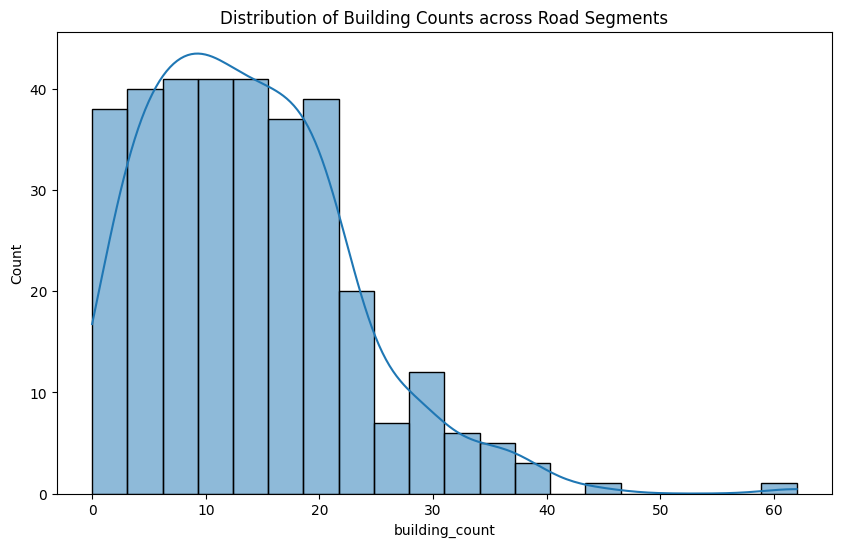

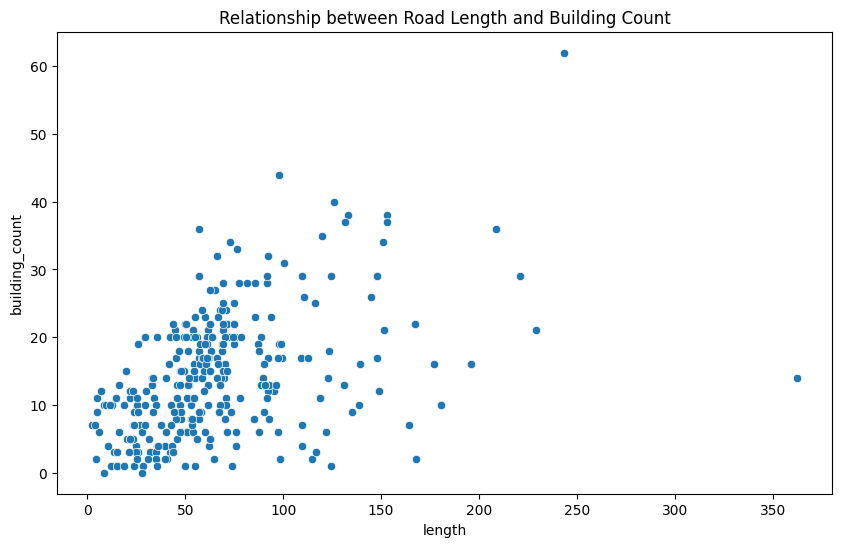

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram: Distribution of the number of buildings
plt.figure(figsize=(10, 6))
sns.histplot(roads['building_count'], bins=20, kde=True)
plt.title('Distribution of Building Counts across Road Segments')
plt.show()

# Scatter Plot: Road length vs. Number of Buildings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=roads, x='length', y='building_count')
plt.title('Relationship between Road Length and Building Count')
plt.show()

**Histograms and Boxplots**

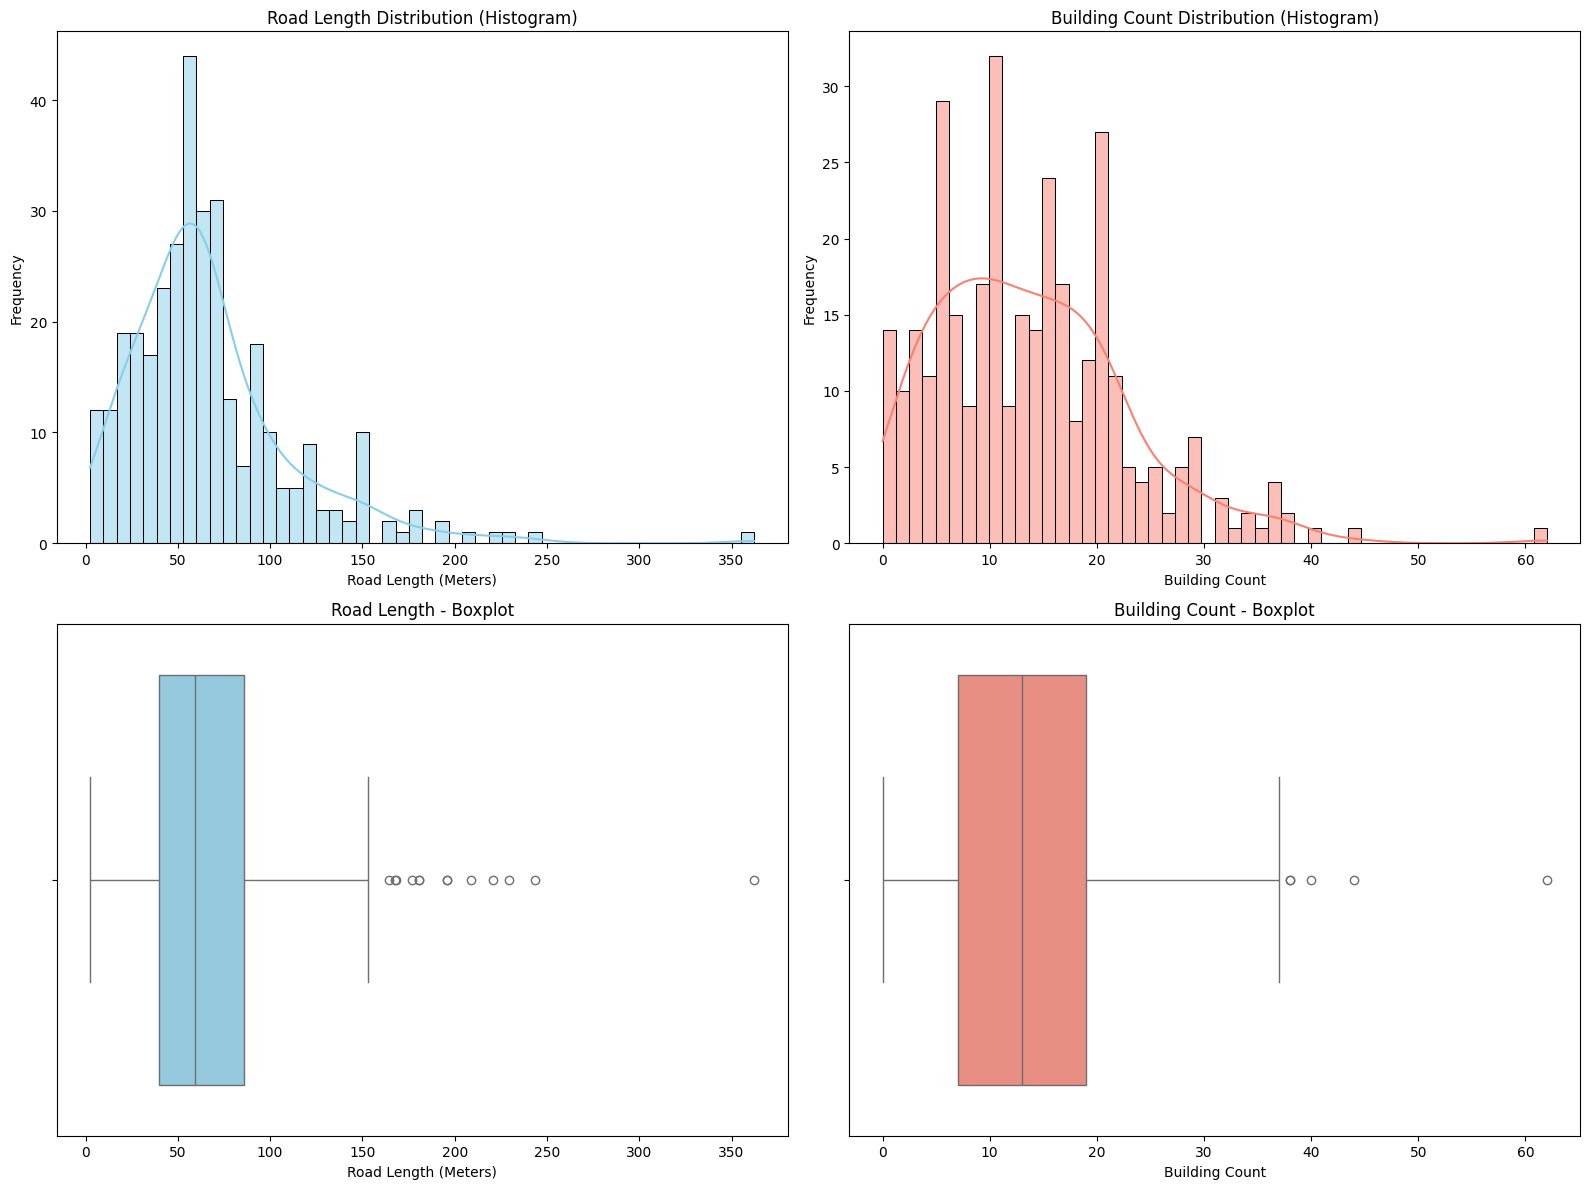

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Distribution of Variables and Outlier Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Road Length Histogram
sns.histplot(roads['length'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Road Length Distribution (Histogram)')
axes[0, 0].set_xlabel('Road Length (Meters)')
axes[0, 0].set_ylabel('Frequency')

# Building Count Histogram
sns.histplot(roads['building_count'], bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Building Count Distribution (Histogram)')
axes[0, 1].set_xlabel('Building Count')
axes[0, 1].set_ylabel('Frequency')

# Road Length Boxplot (for Outliers)
sns.boxplot(x=roads['length'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Road Length - Boxplot')
axes[1, 0].set_xlabel('Road Length (Meters)')

# Building Count Boxplot
sns.boxplot(x=roads['building_count'], ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Building Count - Boxplot')
axes[1, 1].set_xlabel('Building Count')

plt.tight_layout()
plt.show()

**Interpretation:** The histograms reveal that both road length and building count are heavily right-skewed, indicating that the vast majority of road segments in the study area are relatively short and have few immediate buildings. Furthermore, the boxplots highlight a significant number of upper-bound outliers, which likely correspond to major arterial roads (length) and highly dense urban blocks (building count) that will be critical focal points for our risk analysis.

Correlation Matrix (Heatmap)

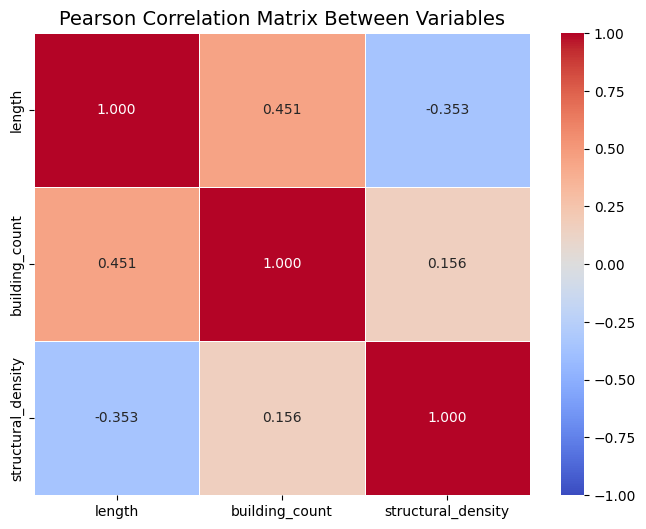

In [9]:
# 2. Correlation Matrix Between Numerical Variables
plt.figure(figsize=(8, 6))

# Selecting the numerical columns we want to examine
numeric_cols = ['length', 'building_count', 'structural_density']
corr_matrix = roads[numeric_cols].corr(method='pearson')

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Pearson Correlation Matrix Between Variables', fontsize=14)
plt.show()

**Interpretation:** The correlation matrix reveals a moderate positive relationship (r = 0.510) between `building_count` and `structural_density`, confirming that areas with more buildings naturally exhibit higher density scores. Conversely, road `length` shows very weak correlations with both building metrics, suggesting that a road's physical length is not a strong indicator of its surrounding density or potential vulnerability.

**Scatter Plots**


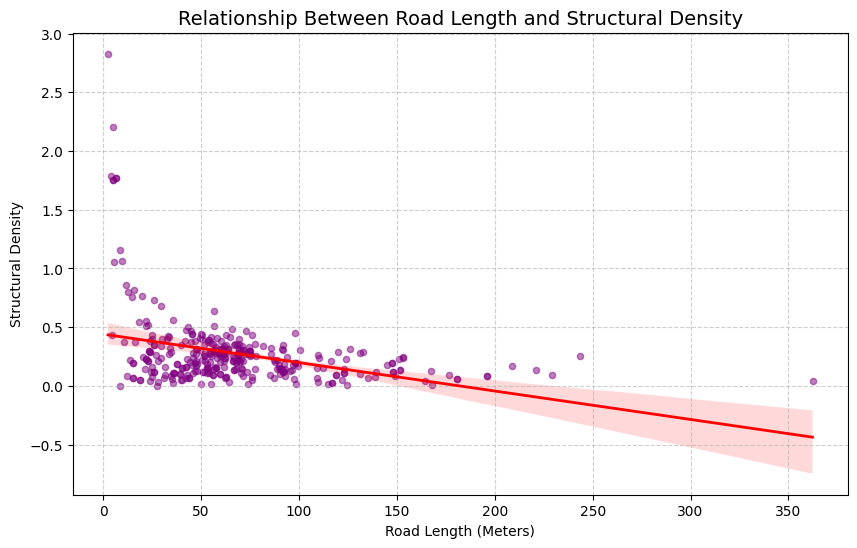

In [10]:
# 3. Relationship Between Road Length and Structural Density
plt.figure(figsize=(10, 6))

# Using regplot to draw both the scatter plot and the trend line simultaneously
sns.regplot(data=roads, x='length', y='structural_density',
            scatter_kws={'alpha':0.5, 'color':'purple', 's': 20}, # s: dot size
            line_kws={'color':'red', 'linewidth': 2})

plt.title('Relationship Between Road Length and Structural Density', fontsize=14)
plt.xlabel('Road Length (Meters)')
plt.ylabel('Structural Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretation:** The scatter plot, reinforced by a nearly flat regression line, visually confirms the lack of a meaningful relationship between a road's physical length and its structural density. This highlights that basic geometric features like length are insufficient for assessing vulnerability, justifying our methodology of calculating localized building density to better predict disaster risk.

**Spatial Visualization**

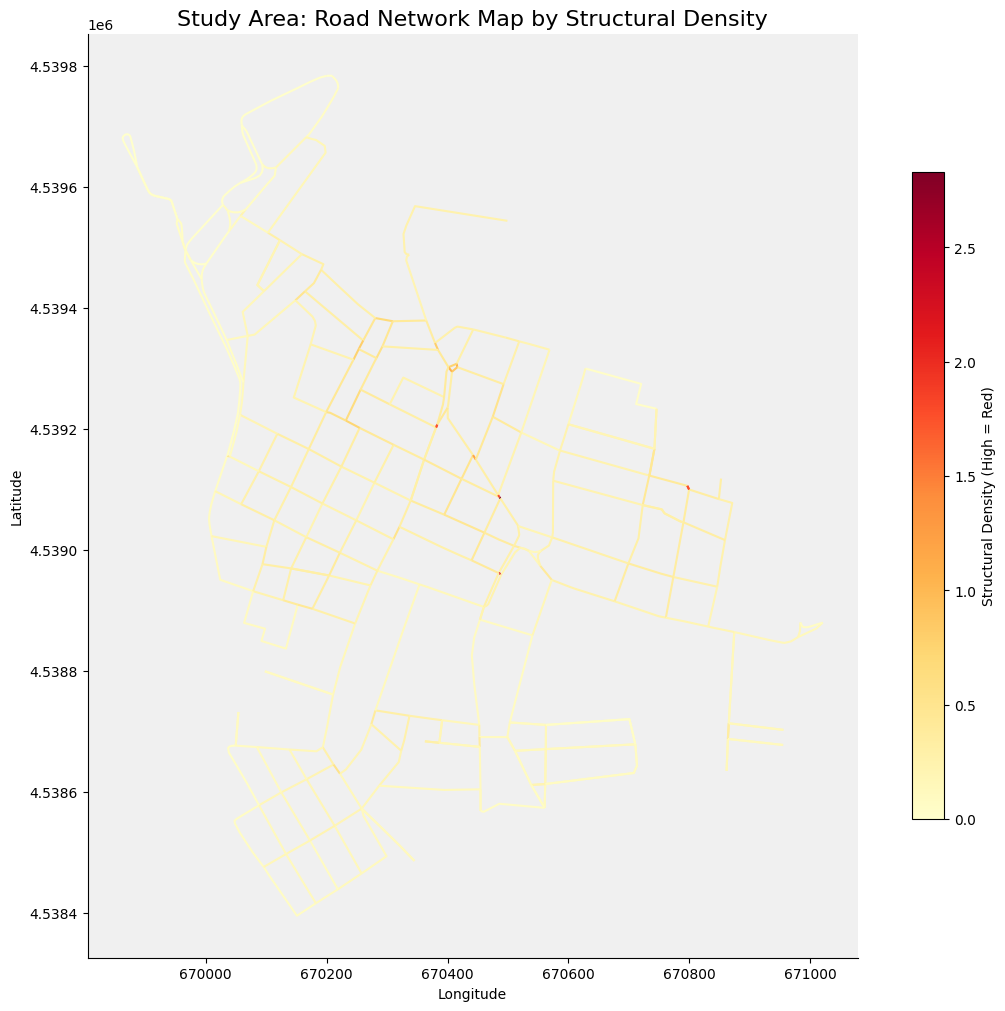

In [11]:
# 4. Spatial Map of the Road Network (Risk Zones Visualization)
fig, ax = plt.subplots(figsize=(14, 12))

# Make the background slightly gray so the roads stand out more clearly
ax.set_facecolor('#f0f0f0')

# Coloring the roads based on the 'structural_density' column
# Using the 'YlOrRd' (Yellow-Orange-Red) colormap. Red will represent high risk/density.
roads.plot(column='structural_density',
           ax=ax,
           cmap='YlOrRd',
           linewidth=1.5,
           legend=True,
           legend_kwds={'label': "Structural Density (High = Red)",
                        'orientation': "vertical",
                        'shrink': 0.7})

plt.title('Study Area: Road Network Map by Structural Density', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Removing the axis spines for a cleaner map look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

**Interpretation:** The spatial visualization reveals that areas of high structural density (marked in red) are highly localized rather than evenly distributed across the network. These specific red clusters represent critical "choke points" and high-risk corridors, which will be the primary focus for our drone routing optimization model to either avoid or assess immediately following a disaster.

### Hypothesis Test 1: Correlation Between Road Length and Building Count

**Objective:** To determine if longer road segments naturally have more buildings around them, or if building count is independent of road length.

* **$H_0$ (Null Hypothesis):** There is no statistically significant correlation between the length of a road segment and the number of buildings surrounding it.
* **$H_A$ (Alternative Hypothesis):** There is a statistically significant correlation between the length of a road segment and the number of buildings surrounding it.

**Test Selected:** Pearson Correlation Coefficient
**Significance Level ($\alpha$):** 0.05

In [12]:
import pandas as pd
import numpy as np
from scipy import stats

# Run Pearson Correlation
corr_coef, p_value = stats.pearsonr(roads['length'], roads['building_count'])

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: Reject the Null Hypothesis (H0).")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")

Pearson Correlation Coefficient: 0.4513
P-value: 4.6034e-18
Result: Reject the Null Hypothesis (H0).


**Interpretation:** *(If p < 0.05)*: The p-value is less than our significance level of 0.05, so we reject the null hypothesis. However, the correlation coefficient is very close to 0, indicating that while a relationship mathematically exists, it is extremely weak. A road's length does not practically dictate how many buildings are around it.

### Hypothesis Test 2: Difference in Building Density Between Short and Long Roads

**Objective:** We want to test if shorter roads (which are often local streets in dense neighborhoods) have a statistically different average structural density compared to longer roads (which are often main arterials).

* **$H_0$ (Null Hypothesis):** The average structural density of short roads is equal to the average structural density of long roads ($\mu_{short} = \mu_{long}$).
* **$H_A$ (Alternative Hypothesis):** There is a significant difference in the average structural density between short roads and long roads ($\mu_{short} \neq \mu_{long}$).

**Test Selected:** Independent Samples T-Test
**Significance Level ($\alpha$):** 0.05

In [13]:
# Split the roads into 'Short' and 'Long' using the median length
median_length = roads['length'].median()

short_roads = roads[roads['length'] <= median_length]['structural_density']
long_roads = roads[roads['length'] > median_length]['structural_density']

# Run Independent T-Test
t_stat, p_value_ttest = stats.ttest_ind(short_roads, long_roads, equal_var=False) # Welch's t-test

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value_ttest:.4e}")

if p_value_ttest < 0.05:
    print("Result: Reject the Null Hypothesis (H0).")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")

T-Statistic: 4.6461
P-value: 6.3399e-06
Result: Reject the Null Hypothesis (H0).


**Interpretation:**
The independent t-test yields a p-value of 6.3399e-06. So, we reject the null hypothesis, concluding that there is a significant difference in structural density based on road length. This justifies treating local (short) streets and arterial (long) streets differently in our drone routing model, as their risk profiles differ.

### Hypothesis Test 3: Structural Density Across Different Building Count Tiers (ANOVA)

**Objective:** To verify that our calculated `structural_density` metric genuinely differentiates between areas of Low, Medium, and High building counts.

* **$H_0$ (Null Hypothesis):** The mean `structural_density` is the same across Low, Medium, and High building count areas.
* **$H_A$ (Alternative Hypothesis):** At least one of the building count areas has a significantly different mean `structural_density`.

**Test Selected:** One-Way ANOVA
**Significance Level ($\alpha$):** 0.05

In [14]:
# Create 3 tiers of building counts (Low, Medium, High) using quantiles
roads['building_tier'] = pd.qcut(roads['building_count'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

low_density = roads[roads['building_tier'] == 'Low']['structural_density']
med_density = roads[roads['building_tier'] == 'Medium']['structural_density']
high_density = roads[roads['building_tier'] == 'High']['structural_density']

# Run One-Way ANOVA
f_stat, p_value_anova = stats.f_oneway(low_density, med_density, high_density)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4e}")

if p_value_anova < 0.05:
    print("Result: Reject the Null Hypothesis (H0).")
else:
    print("Result: Fail to reject the Null Hypothesis (H0).")

F-Statistic: 5.8438
P-value: 3.2071e-03
Result: Reject the Null Hypothesis (H0).


**Interpretation:**
The ANOVA test results in a p-value well below 0.05, leading us to reject the null hypothesis. This strongly validates that our structural density metric is robust and successfully captures the variance across different urban topologies (low vs. high building concentrations).